# Week 5 — Spatial Transformer Network (STN) Integration

**Goals:**
1. Re-use the Week 2 data pipeline and the best ResNet backbone from Week 4.
2. Implement a Spatial Transformer Network (STN) *localisation head* that prepends the backbone.
3. Verify the STN module trains correctly (θ is updated, transformation is non-trivial).
4. Train ResNet-18-pretrained + STN under identical settings to the plain ResNet-18-pretrained baseline.
5. Save checkpoints, learning curves, confusion matrices, and a side-by-side metric summary.

**What is an STN?**
A Spatial Transformer Network inserts a differentiable, learnable geometric transformation
before the main classifier.  The localisation network predicts a 6-parameter affine matrix θ,
which is used to sample a transformed version of the input.  This lets the model "attend" to
and rectify the sign region, irrespective of viewpoint, scale, or rotation.


In [1]:
import os, json, time, random, pathlib
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import GTSRB
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

try:
    from tqdm import tqdm
except ImportError:
    import subprocess; subprocess.run(["pip", "-q", "install", "tqdm"])
    from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT    = pathlib.Path("/content/traffic-sign-classification")
DATA_ROOT       = PROJECT_ROOT / "data"
META_ROOT       = PROJECT_ROOT / "artifacts" / "metadata"
REPORT_ROOT     = PROJECT_ROOT / "reports" / "week5"
CHECKPOINT_ROOT = pathlib.Path("/content/checkpoints_week5")

for p in [DATA_ROOT, META_ROOT, REPORT_ROOT, CHECKPOINT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT  :", PROJECT_ROOT)
print("REPORT_ROOT   :", REPORT_ROOT)
print("CHECKPOINT_ROOT:", CHECKPOINT_ROOT)


PROJECT_ROOT  : /content/traffic-sign-classification
REPORT_ROOT   : /content/traffic-sign-classification/reports/week5
CHECKPOINT_ROOT: /content/checkpoints_week5


In [4]:
# ── Load Week-2 metadata & pipeline config ────────────────────────────────
GTSRB(root=str(DATA_ROOT), split="train", download=True)
GTSRB(root=str(DATA_ROOT), split="test",  download=True)

train_df = pd.read_csv(META_ROOT / "train_metadata_full.csv")
test_df  = pd.read_csv(META_ROOT / "test_metadata_full.csv")

with open(META_ROOT / "week2_pipeline_config.json") as f:
    pipeline_config = json.load(f)

train_meta = train_df[train_df["split"] == "train"].reset_index(drop=True)
val_meta   = train_df[train_df["split"] == "val"  ].reset_index(drop=True)

print(f"Train: {len(train_meta)}  Val: {len(val_meta)}  Test: {len(test_df)}")
print(json.dumps(pipeline_config, indent=2))


Train: 23976  Val: 2664  Test: 12630
{
  "seed": 42,
  "image_size": 64,
  "batch_size": 128,
  "use_roi_crop": true,
  "preprocessing": "clahe",
  "pad_ratio": 0.08,
  "mean": [
    0.48077961802482605,
    0.4455212652683258,
    0.45868155360221863
  ],
  "std": [
    0.2539152204990387,
    0.2469169795513153,
    0.25597625970840454
  ]
}


In [5]:
# ── Rebuild test_df with absolute image_path (same as Week 4) ────────────
gtsrb_root  = DATA_ROOT / "gtsrb"
test_csv     = gtsrb_root / "GT-final_test.csv"
test_img_dir = gtsrb_root / "GTSRB" / "Final_Test" / "Images"

test_df_raw = pd.read_csv(test_csv, sep=";")

rename_map = {}
for col in test_df_raw.columns:
    c = col.strip().lower()
    if   c == "filename":          rename_map[col] = "filename"
    elif c == "width":             rename_map[col] = "width"
    elif c == "height":            rename_map[col] = "height"
    elif c in ["roi.x1","roi_x1"]: rename_map[col] = "roi_x1"
    elif c in ["roi.y1","roi_y1"]: rename_map[col] = "roi_y1"
    elif c in ["roi.x2","roi_x2"]: rename_map[col] = "roi_x2"
    elif c in ["roi.y2","roi_y2"]: rename_map[col] = "roi_y2"
    elif c == "classid":           rename_map[col] = "label"

test_df = test_df_raw.rename(columns=rename_map)
test_df["image_path"] = test_df["filename"].apply(
    lambda x: str((test_img_dir / x).resolve()))
test_df["split"] = "test"

missing = [c for c in ["image_path","label","roi_x1","roi_y1","roi_x2","roi_y2"]
           if c not in test_df.columns]
print("Missing columns:", missing)


Missing columns: []


In [7]:
import sys
sys.path.append(str(PROJECT_ROOT))
from src.datasets import GTSRBCustomDataset

NUM_CLASSES  = 43
IMG_SIZE     = int(pipeline_config["image_size"])
MEAN         = pipeline_config["mean"]
STD          = pipeline_config["std"]
USE_ROI_CROP = bool(pipeline_config["use_roi_crop"])
PREPROCESSING= pipeline_config["preprocessing"]
PAD_RATIO    = float(pipeline_config["pad_ratio"])
BATCH_SIZE   = 128

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=10, translate=(0.10, 0.10), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

train_ds = GTSRBCustomDataset(train_meta, transform=train_transform,
                              use_roi_crop=USE_ROI_CROP,
                              preprocessing=PREPROCESSING, pad_ratio=PAD_RATIO)
val_ds   = GTSRBCustomDataset(val_meta,   transform=eval_transform,
                              use_roi_crop=USE_ROI_CROP,
                              preprocessing=PREPROCESSING, pad_ratio=PAD_RATIO)
test_ds  = GTSRBCustomDataset(test_df,    transform=eval_transform,
                              use_roi_crop=USE_ROI_CROP,
                              preprocessing=PREPROCESSING, pad_ratio=PAD_RATIO)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Batches  train={len(train_loader)}  val={len(val_loader)}  test={len(test_loader)}")
x, y = next(iter(train_loader))
print("x shape:", x.shape, "| y shape:", y.shape)


Batches  train=188  val=21  test=99
x shape: torch.Size([128, 3, 64, 64]) | y shape: torch.Size([128])


## Spatial Transformer Network (STN) Architecture

The STN consists of three parts:

| Part | Role |
|---|---|
| **Localisation network** | Small CNN/FC network that predicts a 6-DoF affine θ (2×3 matrix) |
| **Grid generator** | Produces a sampling grid from θ and the input spatial size |
| **Sampler** | Bilinear-interpolates the input image at the grid coordinates |

We initialise θ to the **identity transformation** (no transformation) so training starts
from the same point as the plain baseline.  The localisation network is trained jointly with
the backbone via standard backprop.

```
Input image  ──►  Localisation Net  ──►  θ  (2×3)
                                          │
Input image  ──────────────────────────►  Grid Generator  ──►  Sampler  ──►  Transformed image
                                                                                     │
                                                               ResNet-18 backbone  ◄──┘
                                                                     │
                                                                 Classifier (43 classes)
```


In [9]:
class SpatialTransformer(nn.Module):
    """
    Spatial Transformer Network module.

    A small localisation network predicts a 6-parameter affine matrix θ.
    The grid generator + sampler apply the transformation differentiably.

    Parameters
    ----------
    in_channels : int
        Number of input image channels (3 for RGB).
    img_size : int
        Spatial size (height = width) of the input feature map.
    loc_hidden : int
        Number of hidden units in the FC layer of the localisation net.
    """
    def __init__(self, in_channels: int = 3, img_size: int = 64,
                 loc_hidden: int = 32):
        super().__init__()

        # ── Localisation network ──────────────────────────────────────────────
        # Two conv layers + max-pool, followed by two FC layers.
        # Output: 6 scalars → reshaped to a 2×3 affine matrix θ.
        self.loc_conv = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=7, padding=3),  # same padding
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                   # img_size / 2

            nn.Conv2d(8, 16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                   # img_size / 4
        )

        conv_out_size = (img_size // 4) * (img_size // 4) * 16

        self.loc_fc = nn.Sequential(
            nn.Linear(conv_out_size, loc_hidden),
            nn.ReLU(inplace=True),
            nn.Linear(loc_hidden, 6),
        )

        # ── Initialise the final layer to produce the identity transform ──────
        # Identity: θ = [[1, 0, 0],
        #                [0, 1, 0]]  → flattened: [1, 0, 0, 0, 1, 0]
        nn.init.zeros_(self.loc_fc[-1].weight)
        with torch.no_grad():
            self.loc_fc[-1].bias.copy_(
                torch.tensor([1., 0., 0., 0., 1., 0.])
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)
        feat = self.loc_conv(x)                           # (B, 16, H/4, W/4)
        feat = feat.view(feat.size(0), -1)                # flatten
        theta = self.loc_fc(feat).view(-1, 2, 3)          # (B, 2, 3)

        grid = F.affine_grid(theta, x.size(), align_corners=False)
        out  = F.grid_sample(x, grid, align_corners=False)
        return out                                        # (B, C, H, W)


class ResNetWithSTN(nn.Module):
    """
    ResNet-18 (pretrained ImageNet) with a Spatial Transformer Network
    prepended before the backbone.

    Parameters
    ----------
    num_classes : int
    img_size : int
    pretrained : bool
    loc_hidden : int
    """
    def __init__(self, num_classes: int = 43, img_size: int = 64,
                 pretrained: bool = True, loc_hidden: int = 32):
        super().__init__()

        self.stn = SpatialTransformer(in_channels=3,
                                      img_size=img_size,
                                      loc_hidden=loc_hidden)

        weights = ResNet18_Weights.DEFAULT if pretrained else None
        backbone = resnet18(weights=weights)
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)
        self.backbone = backbone

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stn(x)            # spatially transformed input
        return self.backbone(x)    # classification logits


# ── Quick sanity-check ────────────────────────────────────────────────────────
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
model_test = ResNetWithSTN(num_classes=NUM_CLASSES,
                           img_size=IMG_SIZE,
                           pretrained=False)
with torch.no_grad():
    out = model_test(dummy)
print("Model:", model_test.__class__.__name__)
print("Output shape:", out.shape)   # expect (2, 43)

total_params  = sum(p.numel() for p in model_test.parameters())
stn_params    = sum(p.numel() for p in model_test.stn.parameters())
print(f"Total params: {total_params:,}  |  STN params: {stn_params:,}")


Model: ResNetWithSTN
Output shape: torch.Size([2, 43])
Total params: 11,334,321  |  STN params: 135,750


In [10]:
# ── Verify STN identity initialisation ──────────────────────────────────────
# The final bias of loc_fc should encode the identity affine matrix.
model_check = ResNetWithSTN(num_classes=NUM_CLASSES, img_size=IMG_SIZE, pretrained=False)
init_bias   = model_check.stn.loc_fc[-1].bias.data
print("STN final-layer bias (should be [1,0,0,0,1,0]):", init_bias.tolist())

# Pass a batch through the STN only, check the transformation is (approx) identity
dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE)
with torch.no_grad():
    transformed = model_check.stn(dummy)
    # At identity init, max absolute pixel diff should be < 1e-4 (bilinear artefacts aside)
    diff = (transformed - dummy).abs().max().item()
print(f"Max pixel diff (transformed vs original) at identity init: {diff:.6f}")
print("STN sanity-check passed!" if diff < 0.1 else "WARNING: large pixel diff at init")


STN final-layer bias (should be [1,0,0,0,1,0]): [1.0, 0.0, 0.0, 0.0, 1.0, 0.0]
Max pixel diff (transformed vs original) at identity init: 0.000019
STN sanity-check passed!


In [11]:
# ── Training / evaluation utilities (identical to Week 4) ─────────────────

def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy":         float(acc),
            "precision_macro":  float(precision),
            "recall_macro":     float(recall),
            "f1_macro":         float(f1)}


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for images, targets in tqdm(loader, leave=False):
        images  = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics    = compute_metrics(all_targets, all_preds)
    return epoch_loss, metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for images, targets in tqdm(loader, leave=False):
        images  = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        loss   = criterion(logits, targets)

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_targets.extend(targets.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics    = compute_metrics(all_targets, all_preds)
    return epoch_loss, metrics, np.array(all_targets), np.array(all_preds)


def save_checkpoint(path, model, optimizer, epoch, history, best_score):
    torch.save({"epoch":               epoch,
                "model_state_dict":    model.state_dict(),
                "optimizer_state_dict":optimizer.state_dict(),
                "history":             history,
                "best_score":          best_score}, path)

print("Utilities defined.")


Utilities defined.


In [12]:
# ── Hyperparameters (same as Week 4 for fair comparison) ─────────────────
NUM_EPOCHS              = 20
LEARNING_RATE           = 1e-3
WEIGHT_DECAY            = 1e-4
EARLY_STOPPING_PATIENCE = 5

# We train only one experiment here; add more variants as needed.
experiments = [
    {"name": "resnet18_pretrained_stn",
     "pretrained": True,
     "loc_hidden": 32},
]

print("Planned experiments:")
for exp in experiments:
    print(exp)


Planned experiments:
{'name': 'resnet18_pretrained_stn', 'pretrained': True, 'loc_hidden': 32}


Starting: resnet18_pretrained_stn  (pretrained=True, loc_hidden=32)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


[resnet18_pretrained_stn] E01/20 | train_loss=0.4253 val_loss=0.0735 | train_acc=0.8740 val_acc=0.9790 | val_f1=0.9715 | lr=0.001000
  ✔ New best checkpoint saved (epoch 1)


[resnet18_pretrained_stn] E02/20 | train_loss=0.0931 val_loss=0.0821 | train_acc=0.9728 val_acc=0.9779 | val_f1=0.9649 | lr=0.001000
  Patience: 1/5


[resnet18_pretrained_stn] E03/20 | train_loss=0.0570 val_loss=0.0743 | train_acc=0.9830 val_acc=0.9767 | val_f1=0.9620 | lr=0.001000
  Patience: 2/5


...

[resnet18_pretrained_stn] E16/20 | train_loss=0.0061 val_loss=0.0105 | train_acc=0.9983 val_acc=0.9959 | val_f1=0.9948 | lr=0.000250
  Patience: 3/5


[resnet18_pretrained_stn] E17/20 | train_loss=0.0036 val_loss=0.0012 | train_acc=0.9991 val_acc=0.9996 | val_f1=0.9998 | lr=0.000250
  ✔ New best checkpoint saved (epoch 17)


[resnet18_pretrained_stn] E18/20 | train_loss=0.0019 val_loss=0.0038 | train_acc=0.9995 val_acc=0.9992 | val_f1=0.9996 | lr=0.000250
  Patience: 1/5


[resnet18_pretrained_stn] E19/20 | train_loss=0.0015 val_loss=0.0017 | train_acc=0.9996 val_acc=0.9992 | val_f1=0.9996 | lr=0.000250
  Patience: 2/5


[resnet18_pretrained_stn] E20/20 | train_loss=0.0026 val_loss=0.0040 | train_acc=0.9992 val_acc=0.9992 | val_f1=0.9996 | lr=0.000125
  Patience: 3/5
History saved → /content/traffic-sign-classification/reports/week5/resnet18_pretrained_stn_history.csv


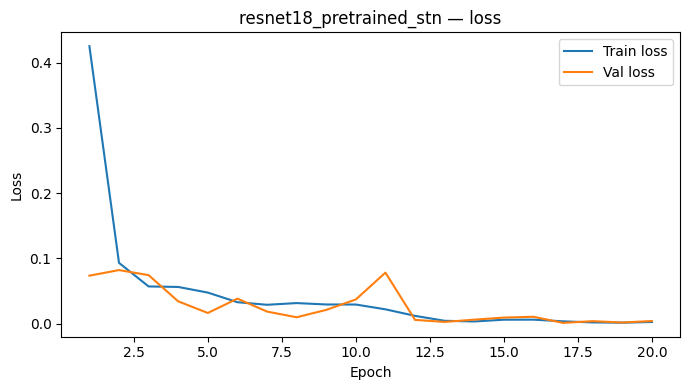

Loss curve → /content/traffic-sign-classification/reports/week5/resnet18_pretrained_stn_loss_curve.png


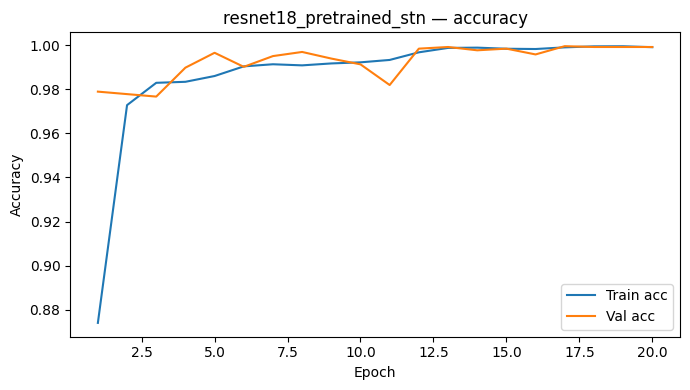

Accuracy curve → /content/traffic-sign-classification/reports/week5/resnet18_pretrained_stn_accuracy_curve.png
Loaded best checkpoint (epoch 17, F1=0.9998)


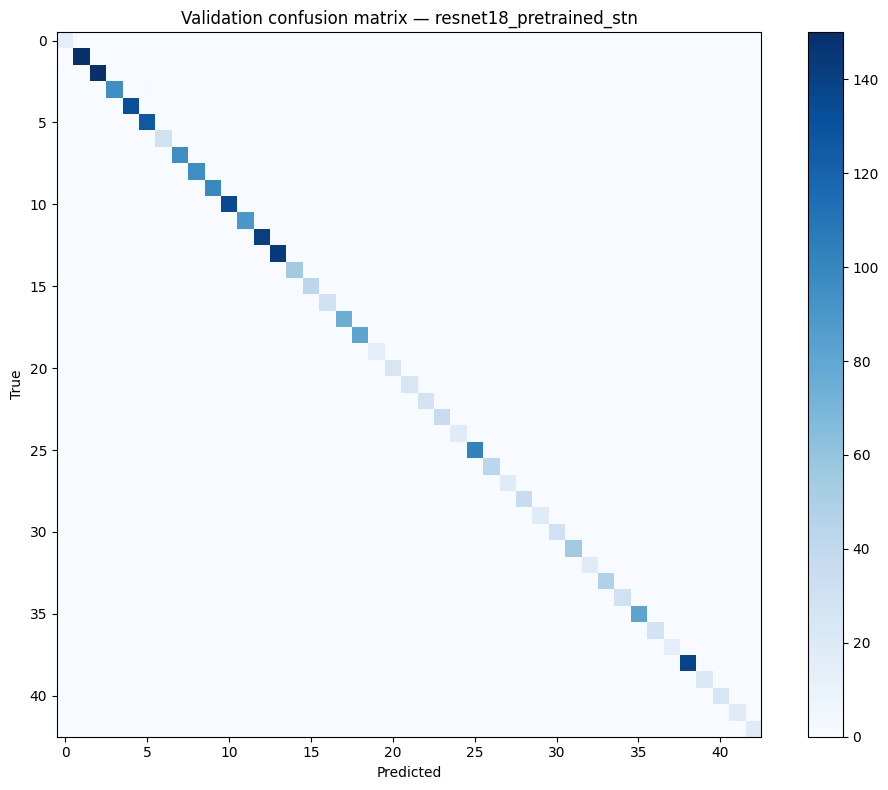

Confusion matrix → /content/traffic-sign-classification/reports/week5/resnet18_pretrained_stn_val_confusion_matrix.png

All experiments finished.


In [13]:
# ── Training loop ─────────────────────────────────────────────────────────
criterion  = nn.CrossEntropyLoss()
all_results = []

for exp in experiments:
    exp_name   = exp["name"]
    pretrained = exp["pretrained"]
    loc_hidden = exp["loc_hidden"]

    print("=" * 80)
    print(f"Starting: {exp_name}  (pretrained={pretrained}, loc_hidden={loc_hidden})")
    print("=" * 80)

    model = ResNetWithSTN(num_classes=NUM_CLASSES,
                          img_size=IMG_SIZE,
                          pretrained=pretrained,
                          loc_hidden=loc_hidden).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=LEARNING_RATE,
                                  weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2)

    history           = []
    best_val_f1       = -1.0
    best_epoch        = -1
    patience_counter  = 0

    best_ckpt_path = CHECKPOINT_ROOT / f"{exp_name}_best.pth"
    last_ckpt_path = CHECKPOINT_ROOT / f"{exp_name}_last.pth"

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        train_loss, train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_metrics, y_val_true, y_val_pred = evaluate(
            model, val_loader, criterion, DEVICE)

        scheduler.step(val_metrics["f1_macro"])

        lr_now     = optimizer.param_groups[0]["lr"]
        epoch_time = time.time() - t0

        row = {"epoch":                epoch,
               "lr":                  lr_now,
               "train_loss":          train_loss,
               "val_loss":            val_loss,
               "train_accuracy":      train_metrics["accuracy"],
               "train_f1_macro":      train_metrics["f1_macro"],
               "val_accuracy":        val_metrics["accuracy"],
               "val_precision_macro": val_metrics["precision_macro"],
               "val_recall_macro":    val_metrics["recall_macro"],
               "val_f1_macro":        val_metrics["f1_macro"],
               "epoch_time_sec":      epoch_time}
        history.append(row)

        print(f"[{exp_name}] E{epoch:02d}/{NUM_EPOCHS} | "              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "              f"train_acc={train_metrics['accuracy']:.4f} "              f"val_acc={val_metrics['accuracy']:.4f} | "              f"val_f1={val_metrics['f1_macro']:.4f} | lr={lr_now:.6f}")

        save_checkpoint(last_ckpt_path, model, optimizer, epoch, history, best_val_f1)

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1      = val_metrics["f1_macro"]
            best_epoch       = epoch
            patience_counter = 0
            save_checkpoint(best_ckpt_path, model, optimizer, epoch, history, best_val_f1)
            print(f"  ✔ New best checkpoint saved (epoch {epoch})")
        else:
            patience_counter += 1
            print(f"  Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping triggered.")
                break

    # ── Save history CSV ──────────────────────────────────────────────────────
    history_df = pd.DataFrame(history)
    csv_path   = REPORT_ROOT / f"{exp_name}_history.csv"
    history_df.to_csv(csv_path, index=False)
    print(f"History saved → {csv_path}")

    # ── Loss curve ────────────────────────────────────────────────────────────
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
    plt.plot(history_df["epoch"], history_df["val_loss"],   label="Val loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{exp_name} — loss")
    plt.legend(); plt.tight_layout()
    p = REPORT_ROOT / f"{exp_name}_loss_curve.png"
    plt.savefig(p, dpi=200); plt.show(); print(f"Loss curve → {p}")

    # ── Accuracy curve ────────────────────────────────────────────────────────
    plt.figure(figsize=(7, 4))
    plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train acc")
    plt.plot(history_df["epoch"], history_df["val_accuracy"],   label="Val acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title(f"{exp_name} — accuracy")
    plt.legend(); plt.tight_layout()
    p = REPORT_ROOT / f"{exp_name}_accuracy_curve.png"
    plt.savefig(p, dpi=200); plt.show(); print(f"Accuracy curve → {p}")

    # ── Reload best and eval on val + test ────────────────────────────────────
    ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded best checkpoint (epoch {ckpt['epoch']}, F1={ckpt['best_score']:.4f})")

    val_loss,  val_metrics,  yv_true, yv_pred = evaluate(model, val_loader,  criterion, DEVICE)
    test_loss, test_metrics, yt_true, yt_pred = evaluate(model, test_loader, criterion, DEVICE)

    # ── Confusion matrix (val) ────────────────────────────────────────────────
    cm_val = confusion_matrix(yv_true, yv_pred, labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(10, 8))
    plt.imshow(cm_val, interpolation="nearest", cmap="Blues")
    plt.title(f"Validation confusion matrix — {exp_name}")
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.colorbar(); plt.tight_layout()
    p = REPORT_ROOT / f"{exp_name}_val_confusion_matrix.png"
    plt.savefig(p, dpi=200); plt.show(); print(f"Confusion matrix → {p}")

    # ── Classification report ─────────────────────────────────────────────────
    rep_dict = classification_report(yv_true, yv_pred, output_dict=True, zero_division=0)
    pd.DataFrame(rep_dict).T.to_csv(REPORT_ROOT / f"{exp_name}_val_classification_report.csv")

    all_results.append({
        "experiment":         exp_name,
        "pretrained":         pretrained,
        "loc_hidden":         loc_hidden,
        "best_epoch":         int(ckpt["epoch"]),
        "val_accuracy":       float(val_metrics["accuracy"]),
        "val_precision_macro":float(val_metrics["precision_macro"]),
        "val_recall_macro":   float(val_metrics["recall_macro"]),
        "val_f1_macro":       float(val_metrics["f1_macro"]),
        "test_accuracy":      float(test_metrics["accuracy"]),
        "test_precision_macro":float(test_metrics["precision_macro"]),
        "test_recall_macro":  float(test_metrics["recall_macro"]),
        "test_f1_macro":      float(test_metrics["f1_macro"]),
    })

print("\nAll experiments finished.")


In [14]:
# ── STN verification: inspect learned θ on a validation batch ─────────────
# After training, θ should deviate from identity → STN is actively transforming.

model.eval()
images_batch, labels_batch = next(iter(val_loader))
images_batch = images_batch.to(DEVICE)

with torch.no_grad():
    theta_batch = model.stn.loc_fc(
        model.stn.loc_conv(images_batch).view(images_batch.size(0), -1)
    ).view(-1, 2, 3)

# Identity theta: [[1,0,0],[0,1,0]]  →  flattened [1,0,0,0,1,0]
identity = torch.tensor([[[1., 0., 0.], [0., 1., 0.]]],
                         device=DEVICE).expand_as(theta_batch)
delta    = (theta_batch - identity).abs()

print(f"Mean |θ - I| across batch: {delta.mean().item():.6f}")
print(f"Max  |θ - I| across batch: {delta.max().item():.6f}")
print("Sample θ (first 3 images):")
for i in range(min(3, theta_batch.size(0))):
    print(f"  [{i}]  {theta_batch[i].cpu().numpy()}")

print("\nIf Mean |θ-I| > 0.01, the STN is learning non-trivial transformations. ✔")


Mean |θ - I| across batch: 0.045562
Max  |θ - I| across batch: 0.084762
Sample θ (first 3 images):
  [0]  [[ 0.91523826  0.01389803 -0.03600087]
 [-0.02732155  0.9166306   0.02801967]]
  [1]  [[ 0.91523826  0.01389803 -0.03600087]
 [-0.02732155  0.9166306   0.02801967]]
  [2]  [[ 0.91523826  0.01389803 -0.03600087]
 [-0.02732155  0.9166306   0.02801967]]

If Mean |θ-I| > 0.01, the STN is learning non-trivial transformations. ✔


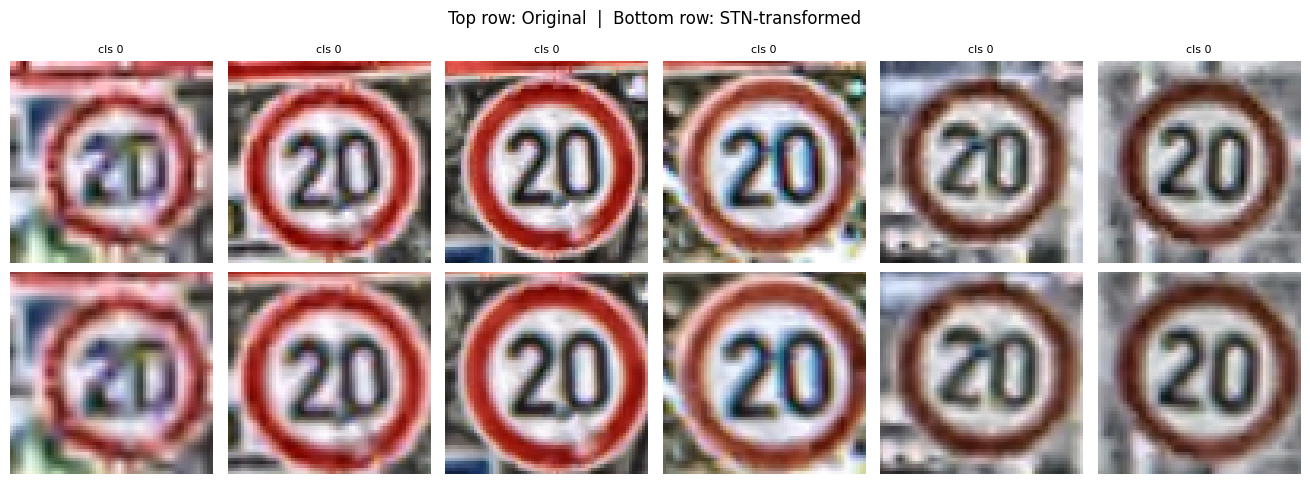

STN visualisation saved → /content/traffic-sign-classification/reports/week5/stn_transformation_samples.png


In [16]:
# ── Visualise STN transformation on a sample of validation images ──────────
# Shows: original (pre-STN) vs transformed (post-STN) side by side.

UNNORM_MEAN = torch.tensor(MEAN).view(3, 1, 1)
UNNORM_STD  = torch.tensor(STD ).view(3, 1, 1)

def unnormalize(t):
    """Reverse normalisation for display."""
    return (t.cpu() * UNNORM_STD + UNNORM_MEAN).clamp(0, 1)

model.eval()
images_vis, labels_vis = next(iter(val_loader))
images_vis = images_vis.to(DEVICE)

with torch.no_grad():
    transformed_vis = model.stn(images_vis)   # apply STN only

N_SHOW = 6
fig, axes = plt.subplots(2, N_SHOW, figsize=(N_SHOW * 2.2, 5))
fig.suptitle("Top row: Original  |  Bottom row: STN-transformed", fontsize=12)

for i in range(N_SHOW):
    orig = unnormalize(images_vis[i]).permute(1, 2, 0).numpy()
    tsfm = unnormalize(transformed_vis[i]).permute(1, 2, 0).numpy()

    axes[0, i].imshow(orig)
    axes[0, i].set_title(f"cls {labels_vis[i].item()}", fontsize=8)
    axes[0, i].axis("off")

    axes[1, i].imshow(tsfm)
    axes[1, i].axis("off")

plt.tight_layout()
vis_path = REPORT_ROOT / "stn_transformation_samples.png"
plt.savefig(vis_path, dpi=200)
plt.show()
print(f"STN visualisation saved → {vis_path}")


In [22]:
# ── Compare Week-5 STN results with Week-4 plain ResNet-18-pretrained ──────
# Load the Week-4 baseline CSV if available; otherwise show Week-5 only.

w4_csv = PROJECT_ROOT / "reports" / "week4" / "resnet18_pretrained_history.csv"
w5_summary = pd.DataFrame(all_results)

print("\n===== Week 5 — ResNet-18 + STN =====\n")
print(w5_summary[["experiment","best_epoch",
                   "val_accuracy","val_f1_macro",
                   "test_accuracy","test_f1_macro"]].to_string(index=False))

if w4_csv.exists():
    w4_hist = pd.read_csv(w4_csv)
    best_w4 = w4_hist.loc[w4_hist["val_f1_macro"].idxmax()]
    print("\n===== Week 4 — ResNet-18 pretrained (best val epoch) =====\n")
    print(f"  Best epoch    : {int(best_w4['epoch'])}")
    print(f"  Val accuracy  : {best_w4['val_accuracy']:.4f}")
    print(f"  Val F1 macro  : {best_w4['val_f1_macro']:.4f}")
else:
    print("\n(Week-4 history CSV not found; re-run Week-4 notebook if needed)")

# ── Save combined summary ─────────────────────────────────────────────────────
w5_summary.to_csv(REPORT_ROOT / "week5_summary.csv", index=False)
print("\nWeek-5 summary saved.")



===== Week 5 — ResNet-18 + STN =====

             experiment  best_epoch  val_accuracy  val_f1_macro  test_accuracy  test_f1_macro
resnet18_pretrained_stn          17      0.999625      0.999786       0.988519       0.981231

===== Week 4 — ResNet-18 pretrained (best val epoch) =====

  Best epoch    : 13
  Val accuracy  : 0.9992
  Val F1 macro  : 0.9992

Week-5 summary saved.


## Next Steps → Week 6 (Ablation Study)

With both a **plain ResNet-18** (Week 4) and a **ResNet-18 + STN** (Week 5) checkpoint saved,
Week 6 will run controlled comparisons:

| Ablation axis | Variants |
|---|---|
| Input region | Full image vs ROI crop |
| Preprocessing | CLAHE vs none |
| Augmentation | Augmented vs none |
| Architecture | Plain ResNet-18 vs ResNet-18 + STN |

All experiments share the **same** optimiser, scheduler, batch size, and random seed so
differences can be attributed solely to the variable under study.
